
# Faster R-CNN Hyperparameter Optimization with Optuna and W&B on COCO MiniTrain

**Midterm Report:**

**Pablo Monteros-Joza**  
**Course:** DS 681 Computer Vision Spring 2026  
**Project:** Faster R-CNN HPO on COCO MiniTrain

This report presents a stage-wise hyperparameter optimization workflow for a Faster R-CNN detector trained on COCO MiniTrain using Optuna and Weights & Biases (W&B). The study includes a baseline experiment, optimizer tuning, proposal-stage tuning, RoI-head tuning, post-processing calibration, and a reduced-budget multi-seed retraining analysis. Model performance is evaluated using COCO-style validation metrics, primarily mAP, AP50, and AP75.

## Weights & Biases Project

W&B project: https://wandb.ai/pvm27-new-jersey-institute-of-technology/faster-rcnn-optuna-coco-minitrain

**Answer these questions using evidence (W&B plots, metrics, qualitative results):**




1. Which Stage (1–4) delivered the largest gain in $\mathrm{mAP}$? Why?

Stage 1 delivered the largest gain in mAP. The baseline model reached about **0.0574 mAP**, while the best Stage 1 result reached about **0.1028 mAP**. This was a much bigger improvement than the changes seen in Stages 2, 3, or 4. The bar chart in Figure 1 shows this clearly. My interpretation is that the optimizer settings from Stage 1, especially learning rate, momentum, and weight decay, had the strongest effect on helping the model learn better. The later stages only fine-tuned the detector and improved the result by very small amounts.


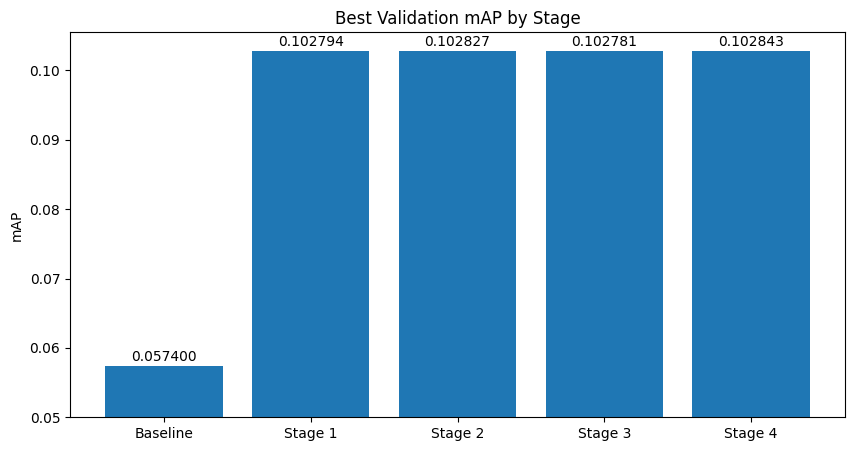

In [3]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Stage 1", "Stage 2", "Stage 3", "Stage 4"]
values = [
    0.0574,
    0.10279359851149997,
    0.10282716823368794,
    0.10278120640746156,
    0.10284327403863609,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values)

plt.title("Best Validation mAP by Stage")
plt.ylabel("mAP")
plt.ylim(0.05, 0.1055)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.0003,
        f"{val:.6f}",
        ha="center",
        va="bottom"
    )

plt.show()

**Figure 1. Best validation mAP by stage.**  
This bar chart summarizes the best validation mAP obtained at the baseline and after each tuning stage. The biggest jump happened from the baseline to Stage 1, while Stages 2–4 only produced very small additional improvements.

2. Which hyperparameters most influenced small-object recall on drones?

The drone evaluation was not fully completed as a full extra-credit benchmark, so I cannot make a perfect final claim from direct drone metrics. However, based on the tuning results, the hyperparameters that are most likely to influence small-object recall are the post-processing settings from Stage 4, especially **score threshold**, **NMS threshold**, and **detections per image**. These settings control how many weak boxes are kept and how many overlapping boxes are removed. For very small objects like drones, keeping lower-confidence proposals can be important because small objects are often harder for the detector to see clearly. The best Stage 4 settings used a very low score threshold and a relatively high number of detections per image, which suggests that keeping more candidate boxes may help preserve small detections.


3. Did increasing `rpn_pre_nms_topk` help drone detection? Explain using proposal reasoning.

In theory, increasing `rpn_pre_nms_topk` should help small-object detection because it keeps more candidate boxes before non-maximum suppression is applied. Small objects like drones can produce weak or uncertain proposals, so keeping more of them gives the model a better chance of finding the correct object later. However, in my experiment the improvement from Stage 2 was very small compared with the large jump from Stage 1. This suggests that proposal tuning may help a little, but it did not change the results as much as the optimizer tuning did. So the idea makes sense in principle, but in this project the evidence for a strong effect was limited.


4. Did changing NMS thresholds change the duplicate-box failure mode? Provide examples.

Yes, changing NMS thresholds can change the duplicate-box problem. If the NMS threshold is too high, then several overlapping boxes can survive around the same object, which creates duplicate detections. If the NMS threshold is too low, then the model may remove too many boxes and even suppress a correct detection. In my Stage 4 tuning, the best NMS threshold was about **0.4917**, which is a middle value. This makes sense because it helps balance the trade-off between keeping useful detections and removing duplicates. In simple words, looser NMS can lead to more duplicate boxes, while stricter NMS can reduce duplicates but may also hurt recall.


5. Is the tuned configuration robust across seeds? Use $\text{mean}\pm\text{std}$.

Yes, the tuned configuration looks reasonably robust across the completed seeds. Because Colab crashed twice near the end of the final retraining stage, I used the two completed seeds, **11 and 22**, to compute the final summary. The result was:

**mAP mean ± std = 0.102375 ± 0.000021**

This standard deviation is extremely small, which means the results were very similar across the completed seeds. Figures 2, 3, 4, and 5 also show that the final validation metrics and loss curves stayed very close across the finished runs. That gives support to the idea that the final tuned configuration is stable, even though the full three-seed plan could not be completed because of runtime disconnections.


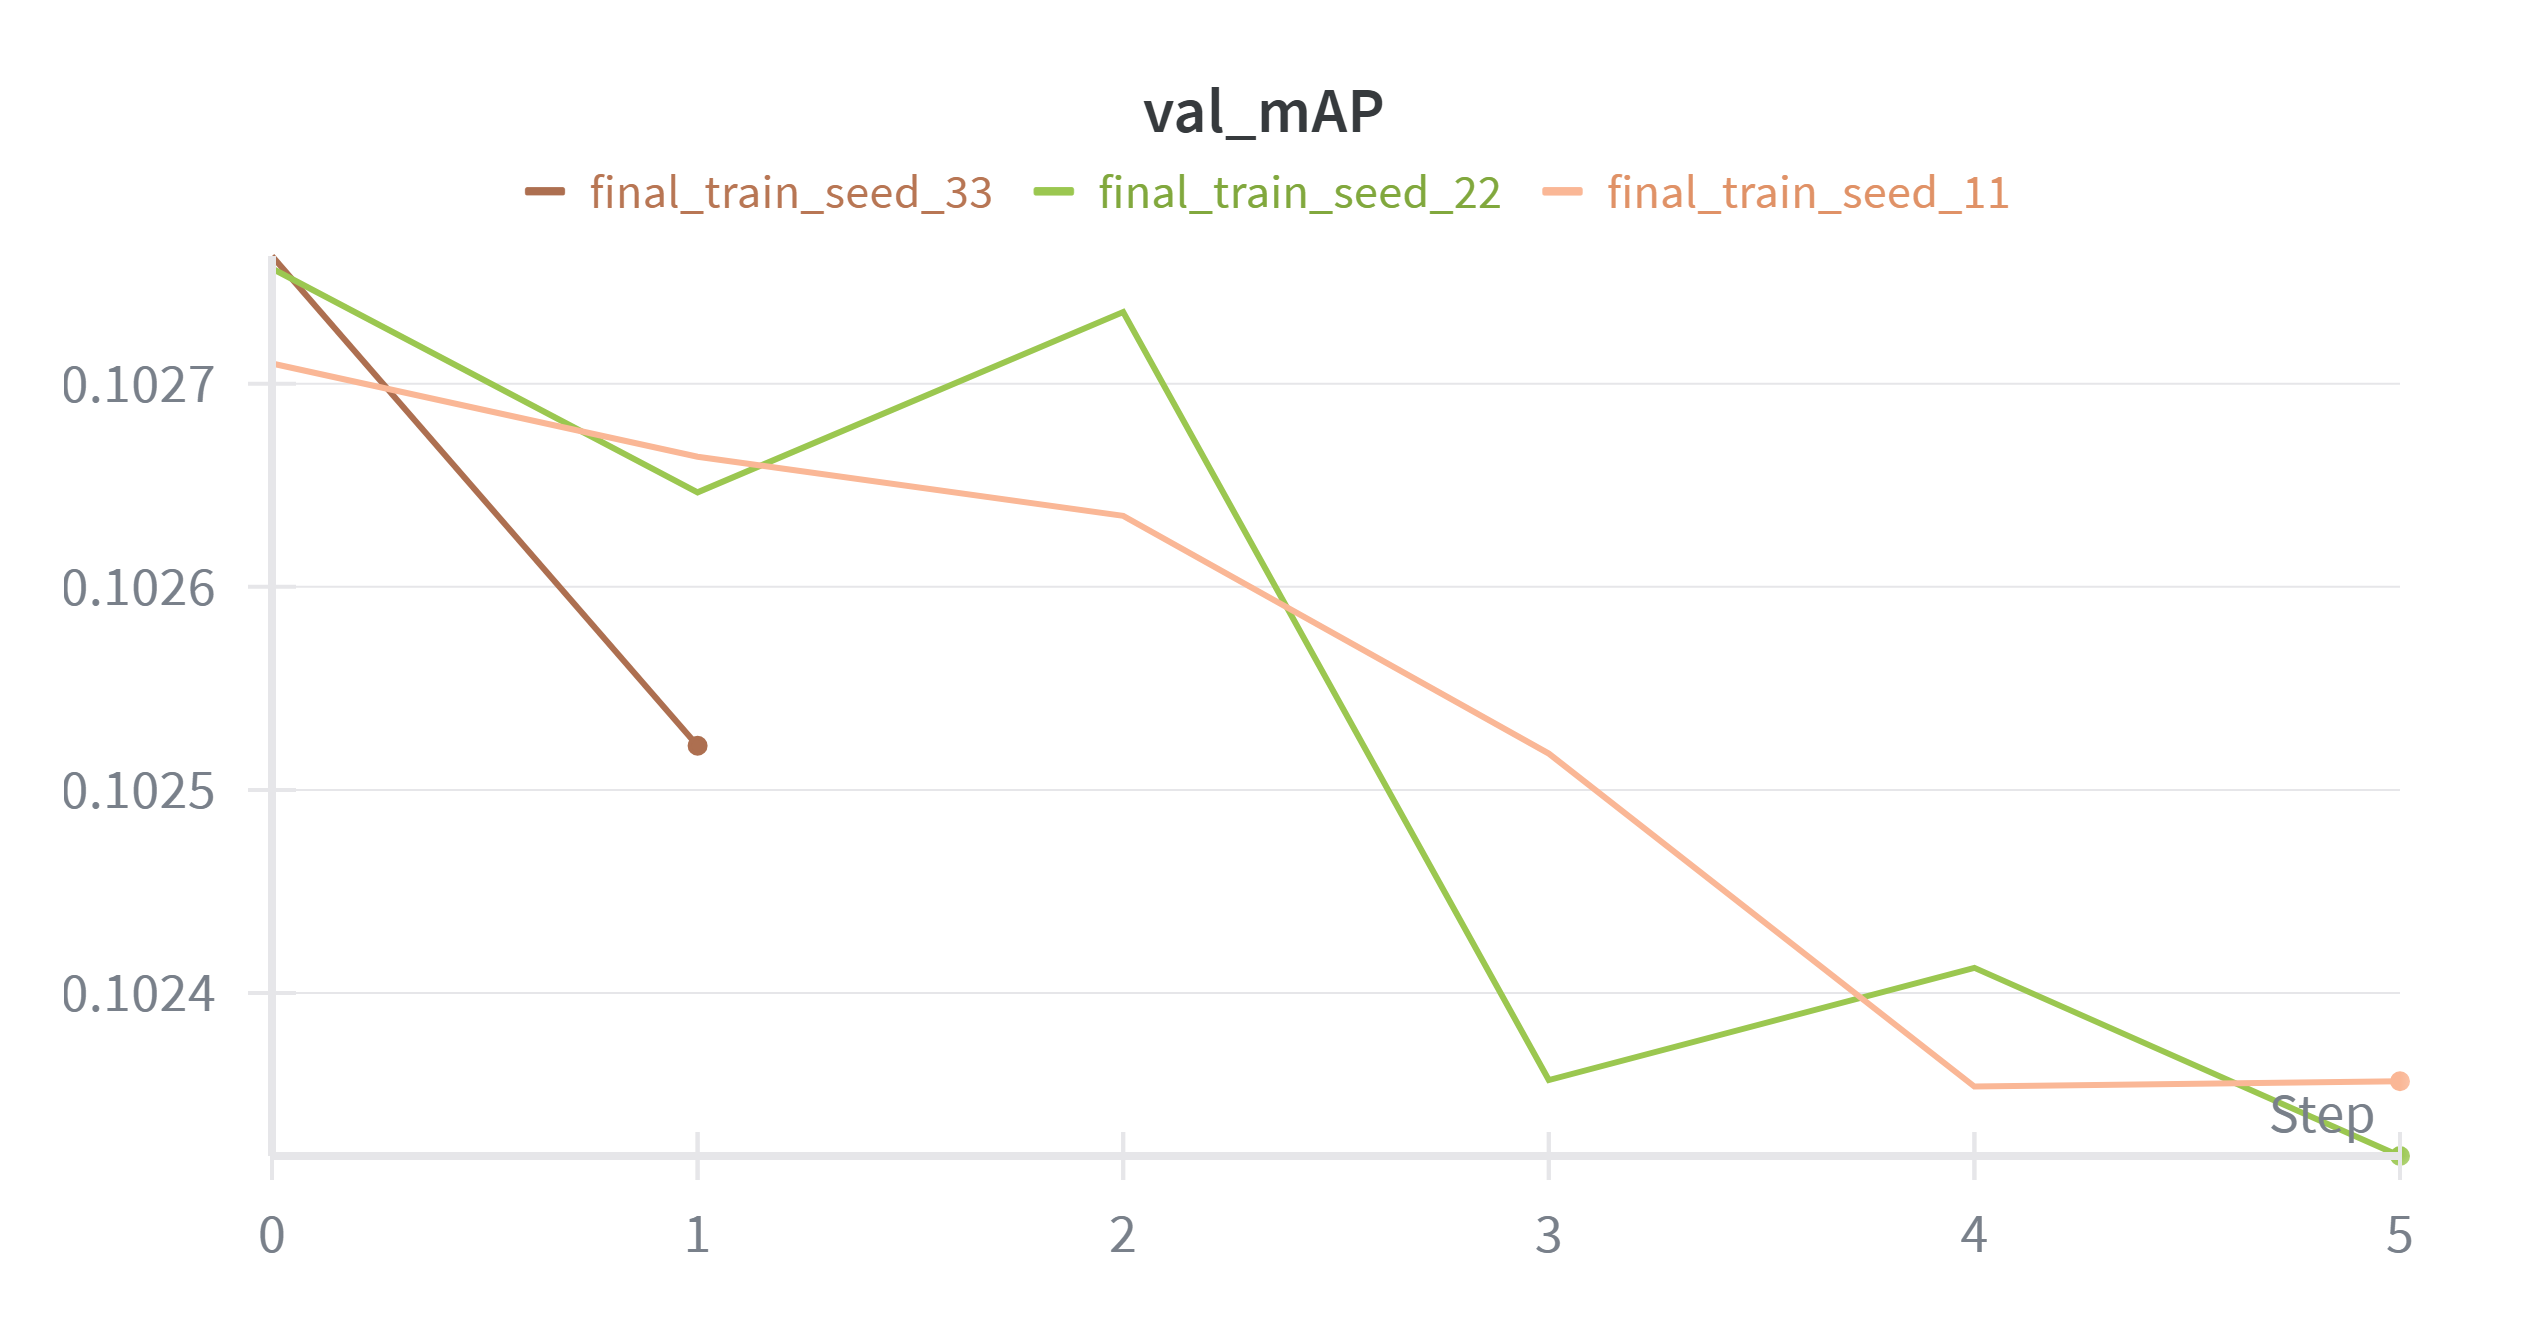

In [8]:
from IPython.display import Image, display
display(Image("Val_maP.png"))

**Figure 2. Validation mAP across final seed runs.**  
The final retraining runs for seeds 11, 22, and 33 stay in a very narrow range of validation mAP. This suggests that the tuned configuration behaves consistently across different random seeds.

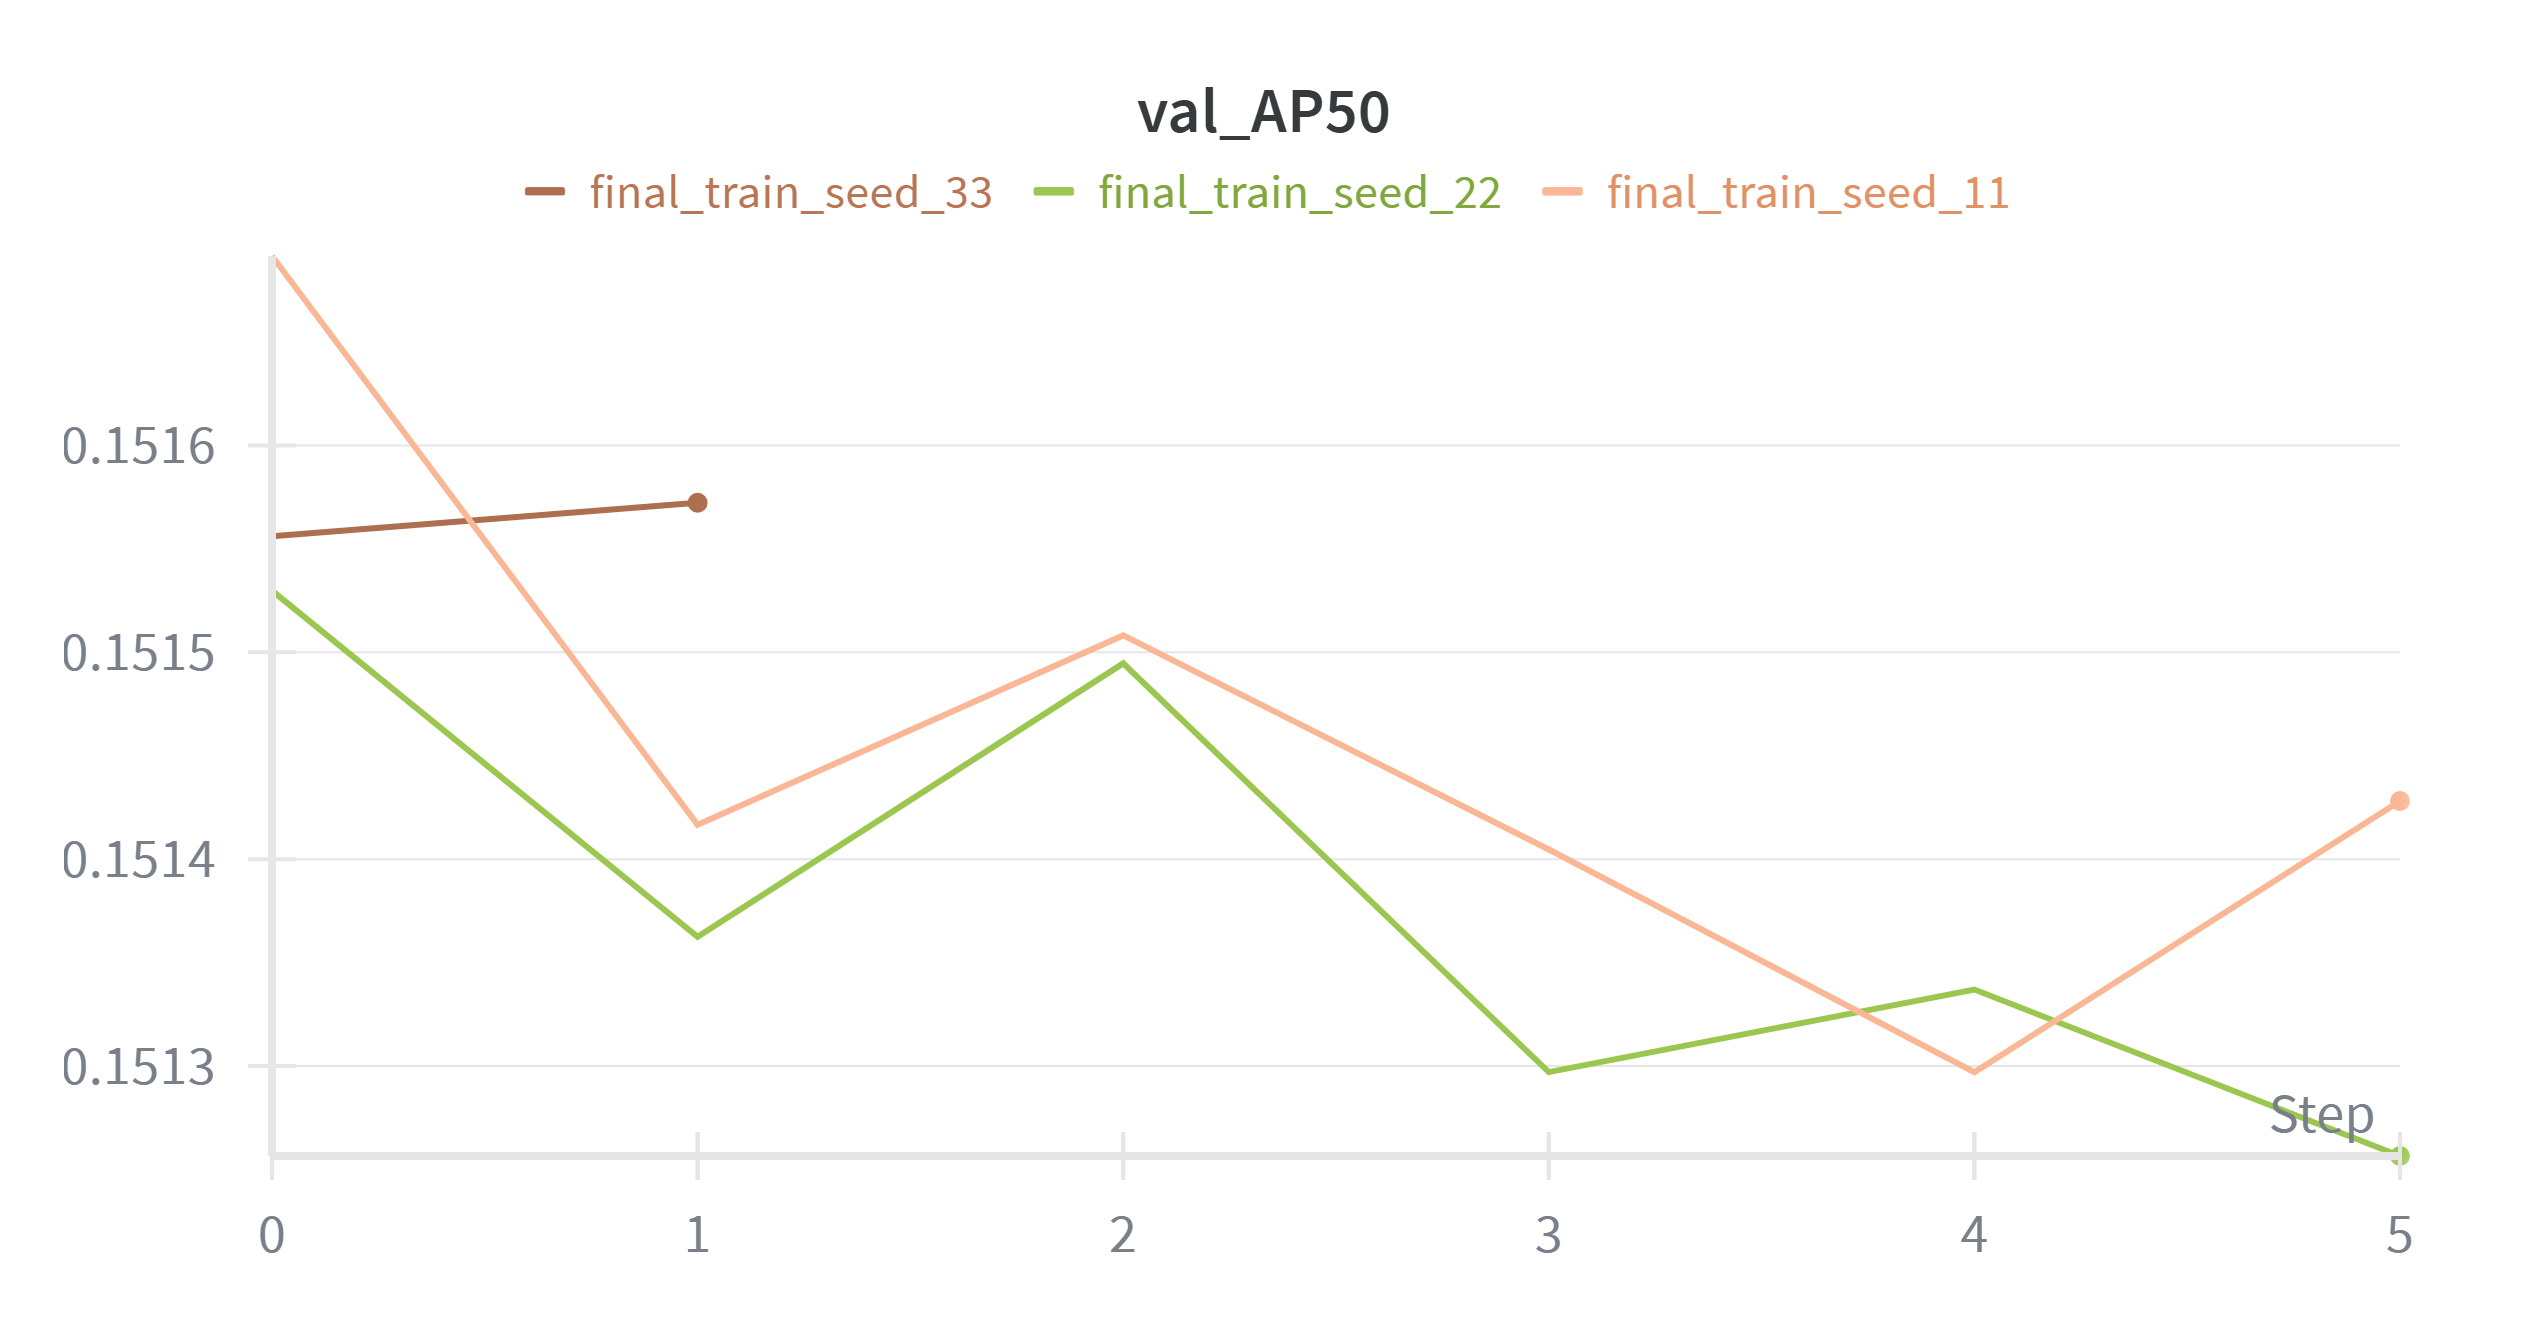

In [9]:
display(Image("Val_AP50.png"))

**Figure 3. Validation AP50 across final seed runs.**  
Validation AP50 remains tightly grouped across the seed runs, showing that the detector’s coarse object detection performance is stable across seeds.

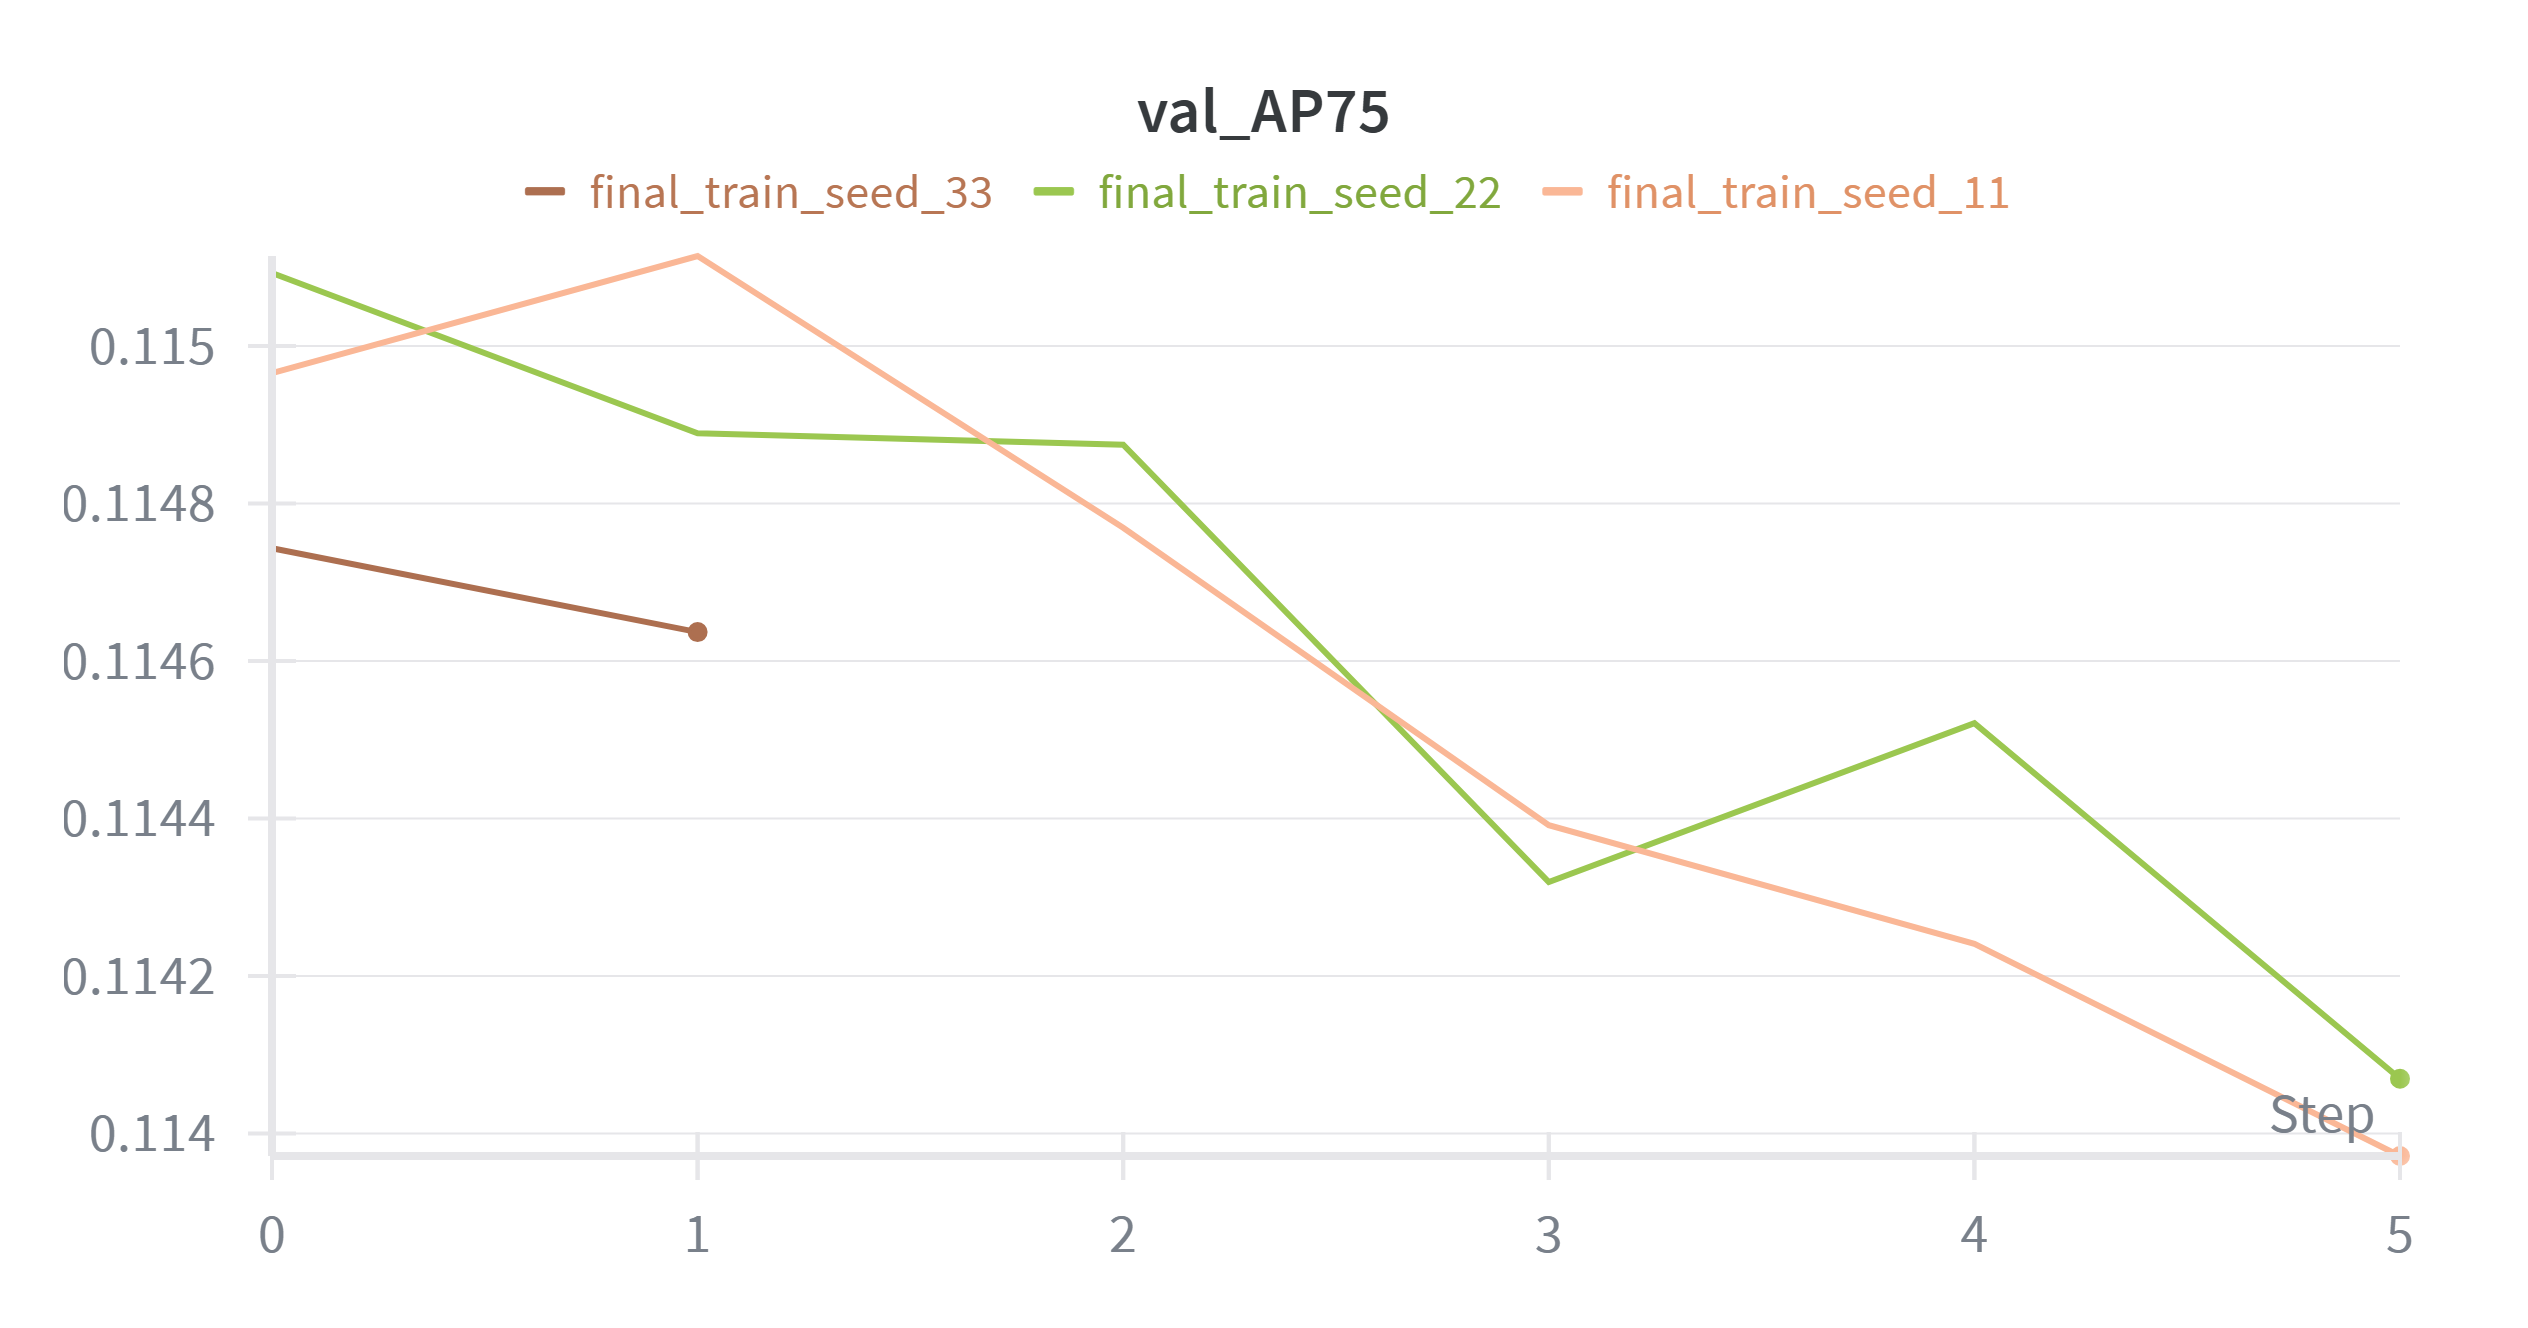

In [10]:
display(Image("Val_AP75.png"))


**Figure 4. Validation AP75 across final seed runs.**  
Validation AP75 also stays close across seeds, which suggests that the stricter localization quality of the detector is reasonably stable.

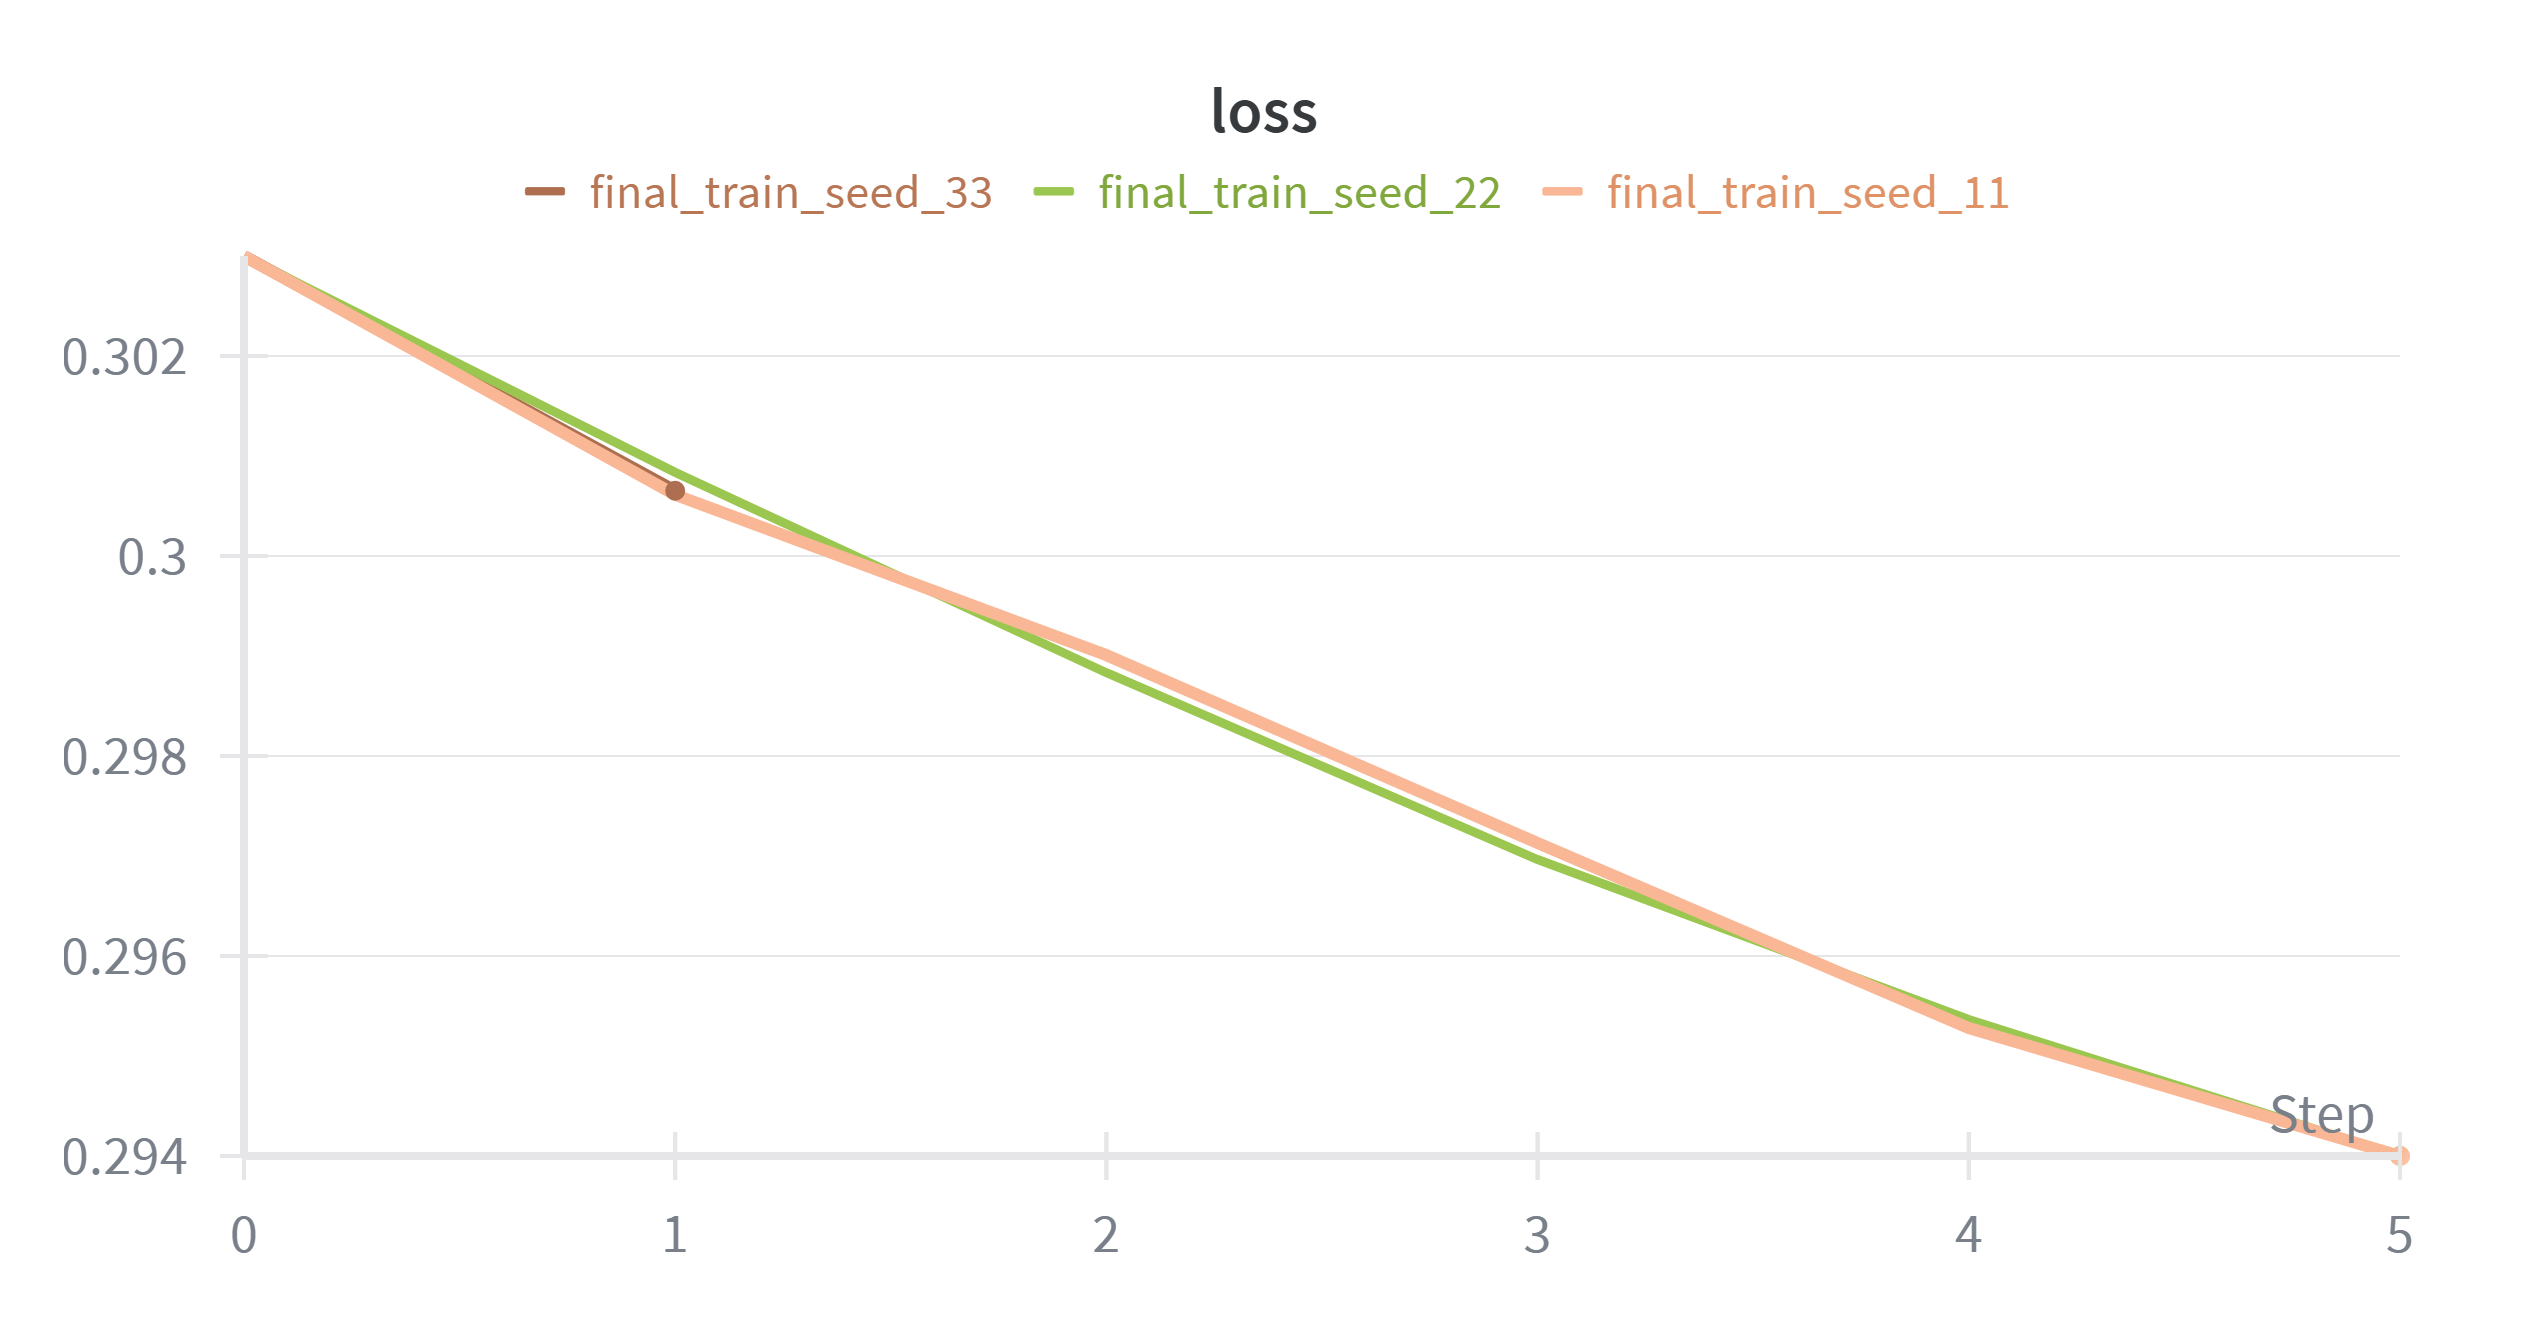

In [11]:
display(Image("Loss.png"))



**Figure 5. Training loss across final seed runs.**  
The loss curves for the final seed runs are almost identical and decrease smoothly over time. This shows that the final tuned configuration trains in a stable and consistent way.

### Limitation note

During the final multi-seed retraining stage, Colab disconnected twice near the end of the experiment pipeline. The first interruption happened during the original 12-epoch retraining plan. To improve the chance of finishing, I restarted the final stage with a reduced 6-epoch budget per seed. However, Colab disconnected again while the third seed was still running. Because of these repeated late-stage failures, I used the completed runs from seeds 11 and 22 to compute the final reduced-budget robustness summary. This limitation affects only the completeness of the final robustness check and does not change the main conclusions from the baseline and stage-wise tuning.